# QUESTION 1

### Part 1

In [1]:
import pandas as pd

df = pd.read_csv("dataset_unscaled.csv")
df['date'] = pd.to_datetime(df['date'])

print("\n1. What is the overall average closing price of gold?")
print(df['close'].mean())


print("\n2. What was the highest gold price ever recorded (High column)?")
print(df['high'].max())


print("\n3. On which date did gold have the lowest closing price?")
print(df.loc[df['close'].idxmin()][['date', 'close']])


print("\n4. Which year had the highest average closing price?")
df['year'] = df['date'].dt.year
print(df.groupby('year')['close'].mean().idxmax())


print("\n5. What is the correlation between gold closing price and USD index?")
print(df[['close', 'usd_index']].corr())


print("\n6. How many days did gold close higher than it opened?")
print((df['close'] > df['open']).sum())


print("\n7. Top 5 dates with the highest volume traded:")
print(df.nlargest(5, 'volume')[['date', 'volume']])


print("\n8. Monthly average gold closing price for each month:")
df['month'] = df['date'].dt.month
print(df.groupby('month')['close'].mean())


print("\n9. Dates where gold price dropped more than 1% from previous day:")
df['Return'] = (df['close'] - df['Close_lag1']) / df['Close_lag1']
result = df[df['Return'] < -0.01][['date', 'close', 'Close_lag1', 'Return']]
print(result)


print("\n10. Yearly maximum 'High' gold price:")
print(df.groupby('year')['high'].max())



1. What is the overall average closing price of gold?
2225.000587201196

2. What was the highest gold price ever recorded (High column)?
4049.199951171875

3. On which date did gold have the lowest closing price?
date     2019-04-23 00:00:00
close            1269.300049
Name: 72, dtype: object

4. Which year had the highest average closing price?
2025

5. What is the correlation between gold closing price and USD index?
              close  usd_index
close      1.000000   0.457772
usd_index  0.457772   1.000000

6. How many days did gold close higher than it opened?
12708

7. Top 5 dates with the highest volume traded:
            date    volume
23395 2025-10-10  352500.0
1563  2019-11-26  346362.0
2061  2020-01-29  251274.0
750   2019-07-29  224267.0
3347  2020-07-29  209835.0

8. Monthly average gold closing price for each month:
month
1     2156.955447
2     2060.270821
3     2122.585547
4     2190.090907
5     2084.011412
6     2030.915683
7     2077.048775
8     2134.355330
9    

## Part 2
### correlation matrix and other graphs made in assignment 1

## Part 3

### KNN For Regression


===== KNN RANGE MODEL METRICS =====
Low R2:  -0.8664
High R2: -0.8348
Range Accuracy: 9.64%

===== SAMPLE PREDICTIONS (10 rows) =====
      Pred Low  Actual Close    Pred High
0  2565.699951   2565.699951  2565.699951
1  2565.699951   2565.699951  2565.699951
2  2565.699951   2565.699951  2565.699951
3  2565.699951   2565.699951  2565.699951
4  2565.699951   2565.699951  2565.699951
5  2565.699951   2565.699951  2565.699951
6  2565.699951   2565.699951  2565.699951
7  2565.699951   2565.699951  2565.699951
8  2565.699951   2565.699951  2565.699951
9  2565.699951   2565.699951  2565.699951


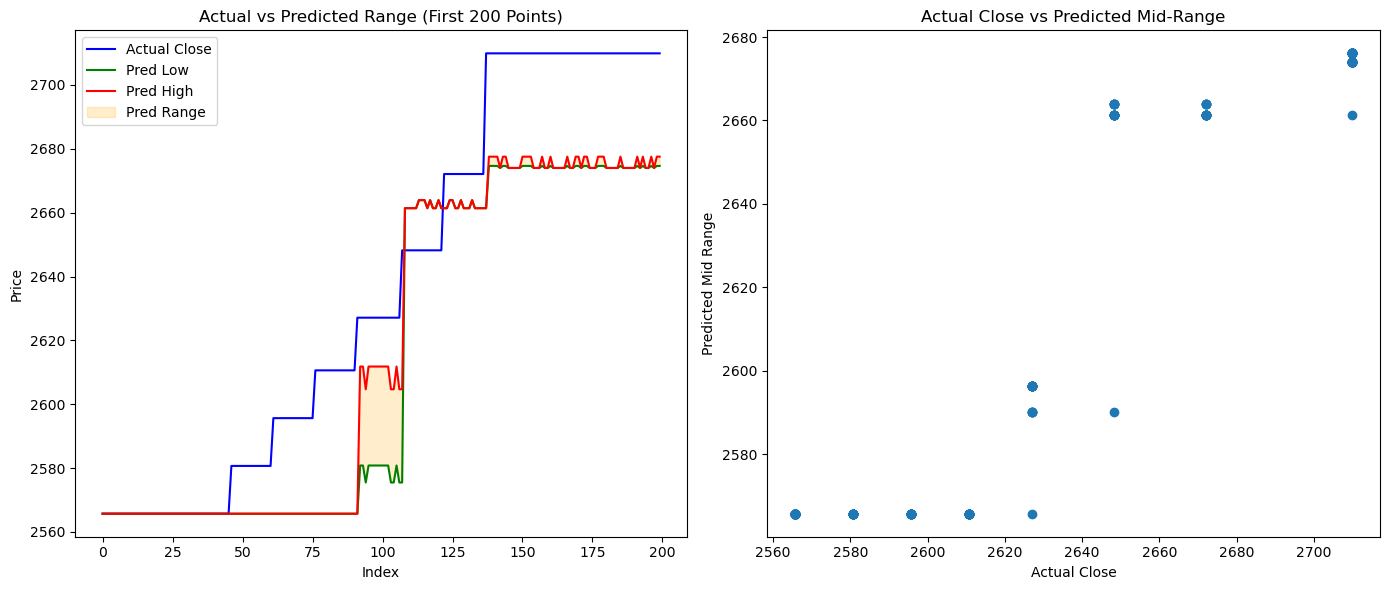

In [1]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("dataset_unscaled.csv")

# --- Create next-day targets ---
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

# Drop last row (because of shift)
df = df.iloc[:-1]

# Feature selection: all numeric except targets
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# ---- TRAIN-TEST SPLIT (time series) ----
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

# ---- Train KNN models ----
knn_low = KNeighborsRegressor(n_neighbors=5, weights="distance")
knn_high = KNeighborsRegressor(n_neighbors=5, weights="distance")

knn_low.fit(X_train, y_low_train)
knn_high.fit(X_train, y_high_train)

# ---- Predictions ----
pred_low = knn_low.predict(X_test)
pred_high = knn_high.predict(X_test)

# ---- Range accuracy ----
correct = (
    (y_close_test >= pred_low) &
    (y_close_test <= pred_high)
).sum()

total = len(y_close_test)
range_accuracy = correct / total

print("\n===== KNN RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high):.4f}")
print(f"Range Accuracy: {range_accuracy * 100:.2f}%")

# ---- Show 10 sample predictions ----
sample = pd.DataFrame({
    "Pred Low": pred_low[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high[:10]
})

print("\n===== SAMPLE PREDICTIONS (10 rows) =====")
print(sample)

# =======================================================
# ===============      VISUALIZATION     ================
# =======================================================

# Midpoint of predicted range (for scatter plot)
pred_mid = (pred_low + pred_high) / 2

# Plot only first 200 for readability
N = 200
y_close_200 = y_close_test[:N]
pred_low_200 = pred_low[:N]
pred_high_200 = pred_high[:N]
pred_mid_200 = pred_mid[:N]

plt.figure(figsize=(14,6))

# --- Plot 1: Actual close + predicted low/high (range band) ---
plt.subplot(1,2,1)
plt.plot(y_close_200.values, label="Actual Close", color="blue")
plt.plot(pred_low_200, label="Pred Low", color="green")
plt.plot(pred_high_200, label="Pred High", color="red")
plt.fill_between(range(N), pred_low_200, pred_high_200, color="orange", alpha=0.2, label="Pred Range")
plt.title("Actual vs Predicted Range (First 200 Points)")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()

# --- Plot 2: Scatter of actual close vs midpoint of predicted range ---
plt.subplot(1,2,2)
plt.scatter(y_close_200, pred_mid_200)
plt.title("Actual Close vs Predicted Mid-Range")
plt.xlabel("Actual Close")
plt.ylabel("Predicted Mid Range")

plt.tight_layout()
plt.show()


## Decision Tree (Regression)


===== DECISION TREE RANGE MODEL METRICS =====
Low R2:  -0.7039
High R2: -0.6657
Range Accuracy: 18.06%

===== SAMPLE PREDICTIONS (10 rows) =====
      Pred Low  Actual Close    Pred High
0  2565.699951   2565.699951  2565.699951
1  2565.699951   2565.699951  2565.699951
2  2565.699951   2565.699951  2565.699951
3  2565.699951   2565.699951  2565.699951
4  2565.699951   2565.699951  2565.699951
5  2565.699951   2565.699951  2565.699951
6  2565.699951   2565.699951  2565.699951
7  2565.699951   2565.699951  2565.699951
8  2565.699951   2565.699951  2565.699951
9  2565.699951   2565.699951  2565.699951


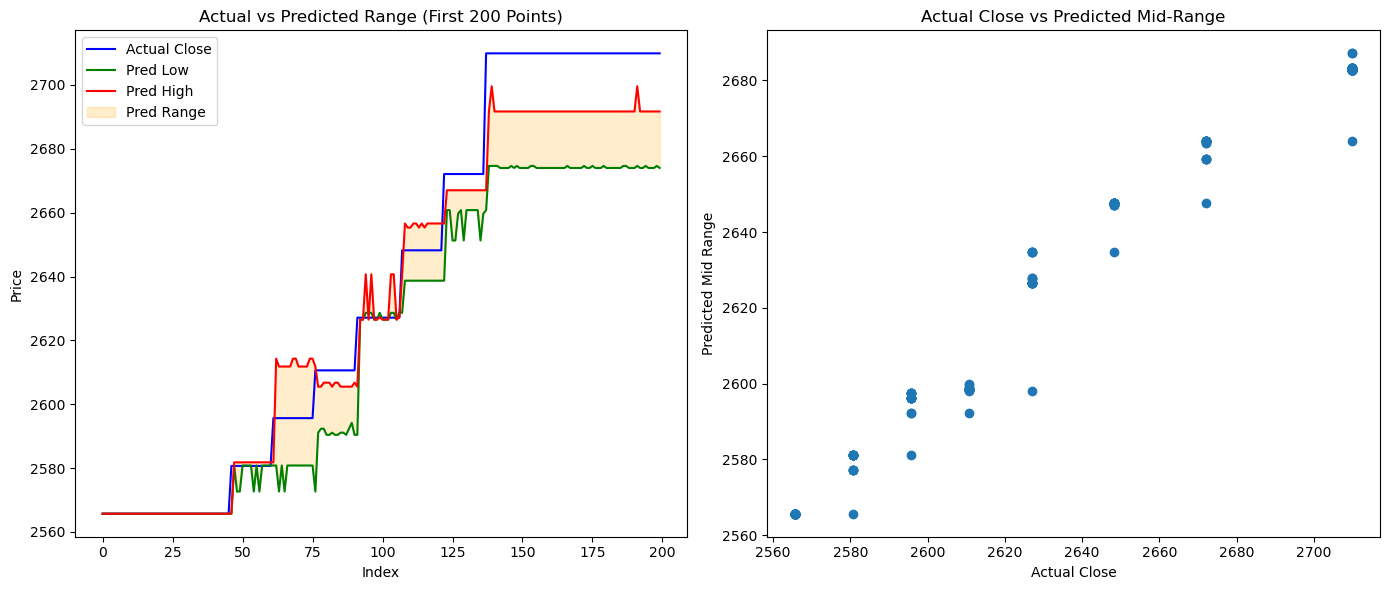

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("dataset_unscaled.csv")

# --- Create next-day targets ---
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

# Drop last row (because of shift)
df = df.iloc[:-1]

# Feature selection: all numeric except targets
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# ---- TRAIN-TEST SPLIT (time series) ----
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

# ---- Train Decision Tree models ----
tree_low = DecisionTreeRegressor(
    max_depth=10,          # you can tune this
    min_samples_leaf=5     # prevents overfitting
)

tree_high = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=5
)

tree_low.fit(X_train, y_low_train)
tree_high.fit(X_train, y_high_train)

# ---- Predictions ----
pred_low = tree_low.predict(X_test)
pred_high = tree_high.predict(X_test)

# ---- Range accuracy ----
correct = ((y_close_test >= pred_low) & (y_close_test <= pred_high)).sum()
total = len(y_close_test)

range_accuracy = correct / total

print("\n===== DECISION TREE RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high):.4f}")
print(f"Range Accuracy: {range_accuracy * 100:.2f}%")

# ---- Show 10 sample predictions ----
sample = pd.DataFrame({
    "Pred Low": pred_low[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high[:10]
})

print("\n===== SAMPLE PREDICTIONS (10 rows) =====")
print(sample)

# =======================================================
# ===============      VISUALIZATION     ================
# =======================================================

# Midpoint of predicted range
pred_mid = (pred_low + pred_high) / 2

# Plot only first 200 for readability
N = 200
y_close_200 = y_close_test[:N]
pred_low_200 = pred_low[:N]
pred_high_200 = pred_high[:N]
pred_mid_200 = pred_mid[:N]

plt.figure(figsize=(14,6))

# --- Plot 1: Actual close + predicted low/high (range band) ---
plt.subplot(1,2,1)
plt.plot(y_close_200.values, label="Actual Close", color="blue")
plt.plot(pred_low_200, label="Pred Low", color="green")
plt.plot(pred_high_200, label="Pred High", color="red")
plt.fill_between(range(N), pred_low_200, pred_high_200, color="orange", alpha=0.2, label="Pred Range")

plt.title("Actual vs Predicted Range (First 200 Points)")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()

# --- Plot 2: Scatter of actual close vs midpoint of predicted range ---
plt.subplot(1,2,2)
plt.scatter(y_close_200, pred_mid_200)
plt.title("Actual Close vs Predicted Mid-Range")
plt.xlabel("Actual Close")
plt.ylabel("Predicted Mid Range")

plt.tight_layout()
plt.show()


## SVM


===== SVM RANGE MODEL METRICS =====
Low R2:  -2.6882
High R2: -2.5565
Range Accuracy: 0.00%

===== SAMPLE PREDICTIONS (10 rows) =====
   Pred Low  Actual Close  Pred High
0  0.566581   2565.699951   0.520795
1  0.572757   2565.699951   0.517088
2  0.572040   2565.699951   0.519362
3  0.563805   2565.699951   0.512951
4  0.576482   2565.699951   0.531927
5  0.568996   2565.699951   0.512320
6  0.572031   2565.699951   0.519625
7  0.570799   2565.699951   0.519742
8  0.571720   2565.699951   0.516838
9  0.571875   2565.699951   0.519578


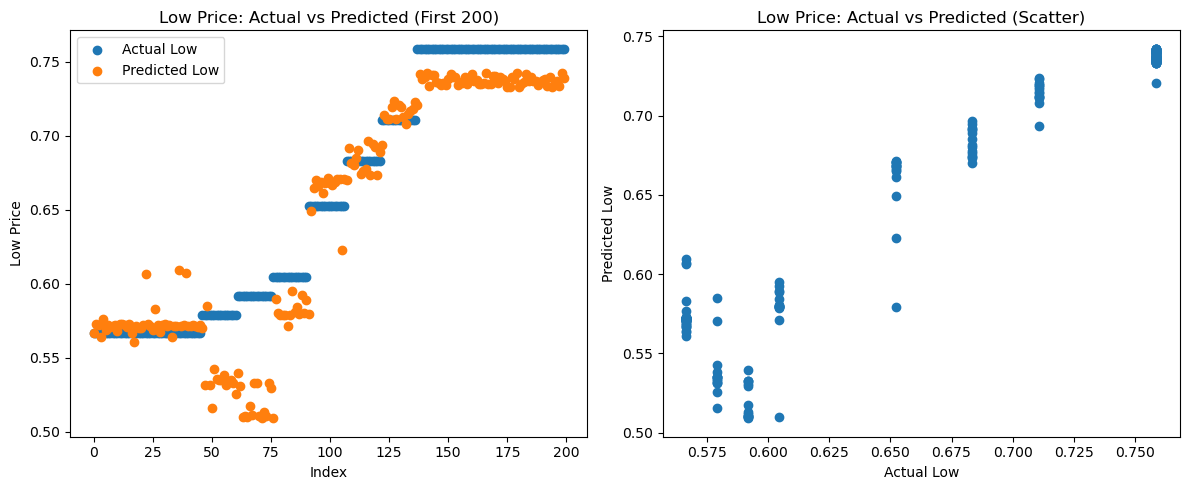

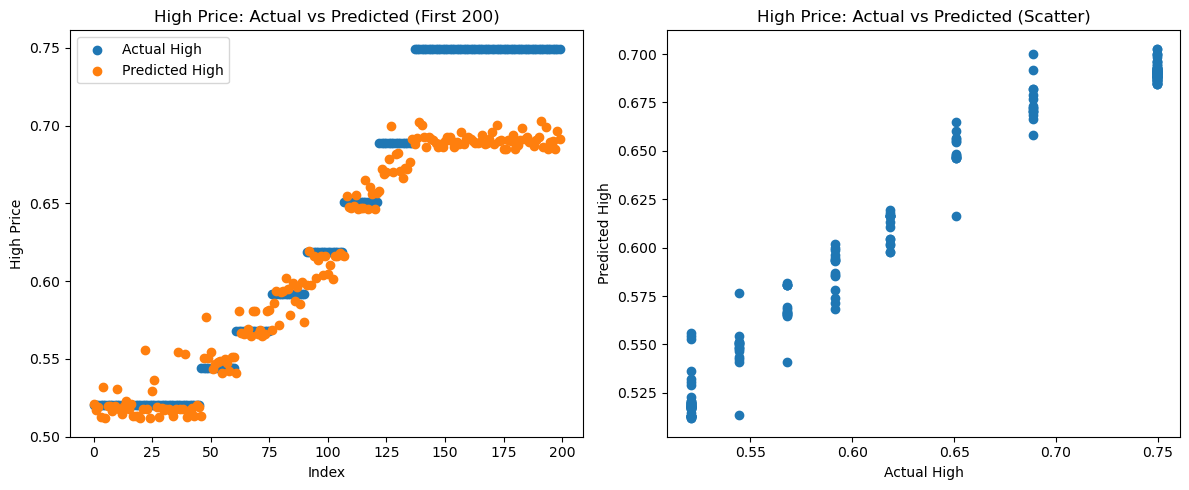

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import r2_score

# ---------------------------
# LOAD DATA (scaled)
# ---------------------------
df = pd.read_csv("dataset_scaled.csv")

# next-day targets
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

# drop last row because of shift
df = df.iloc[:-1]

# FEATURES: all numeric except targets
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# TIME-SERIES TRAIN-TEST SPLIT
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

# ---------------------------
# SVM MODELS
# ---------------------------
# SVR with RBF kernel (good default for regression)
low_model = SVR(kernel="rbf", C=100, epsilon=0.01)
high_model = SVR(kernel="rbf", C=100, epsilon=0.01)

# TRAIN
low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)

# PREDICTIONS
pred_low = low_model.predict(X_test)
pred_high = high_model.predict(X_test)

# ---------------------------
# RANGE ACCURACY
# ---------------------------
correct = ((y_close_test >= pred_low) & (y_close_test <= pred_high)).sum()
range_accuracy = correct / len(y_close_test)

# ---------------------------
# METRICS
# ---------------------------
print("\n===== SVM RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high):.4f}")
print(f"Range Accuracy: {range_accuracy * 100:.2f}%")

# SAMPLE OUTPUT
sample = pd.DataFrame({
    "Pred Low": pred_low[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high[:10]
})
print("\n===== SAMPLE PREDICTIONS (10 rows) =====")
print(sample)

# ---------------------------
# VISUALIZATION — LOW
# ---------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(range(len(y_low_test[:200])), y_low_test[:200], label="Actual Low")
plt.scatter(range(len(pred_low[:200])), pred_low[:200], label="Predicted Low")
plt.title("Low Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("Low Price")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_low_test[:200], pred_low[:200])
plt.title("Low Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual Low")
plt.ylabel("Predicted Low")

plt.tight_layout()
plt.show()


# ---------------------------
# VISUALIZATION — HIGH
# ---------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(range(len(y_high_test[:200])), y_high_test[:200], label="Actual High")
plt.scatter(range(len(pred_high[:200])), pred_high[:200], label="Predicted High")
plt.title("High Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("High Price")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_high_test[:200], pred_high[:200])
plt.title("High Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual High")
plt.ylabel("Predicted High")

plt.tight_layout()
plt.show()


## Enssemble Learning Algorithms


===== RANGE MODEL METRICS =====
Low R2:  -0.6602
High R2: -0.7065
Range Accuracy: 20.84%

===== SAMPLE PREDICTIONS (10 rows) =====
      Pred Low  Actual Close    Pred High
0  2565.297865   2565.699951  2565.476820
1  2565.273802   2565.699951  2567.369859
2  2565.273802   2565.699951  2566.194016
3  2565.297865   2565.699951  2565.476820
4  2565.297865   2565.699951  2566.142331
5  2565.297865   2565.699951  2565.476820
6  2565.273802   2565.699951  2566.268801
7  2565.297865   2565.699951  2565.476820
8  2565.297865   2565.699951  2565.476820
9  2565.273802   2565.699951  2565.476820


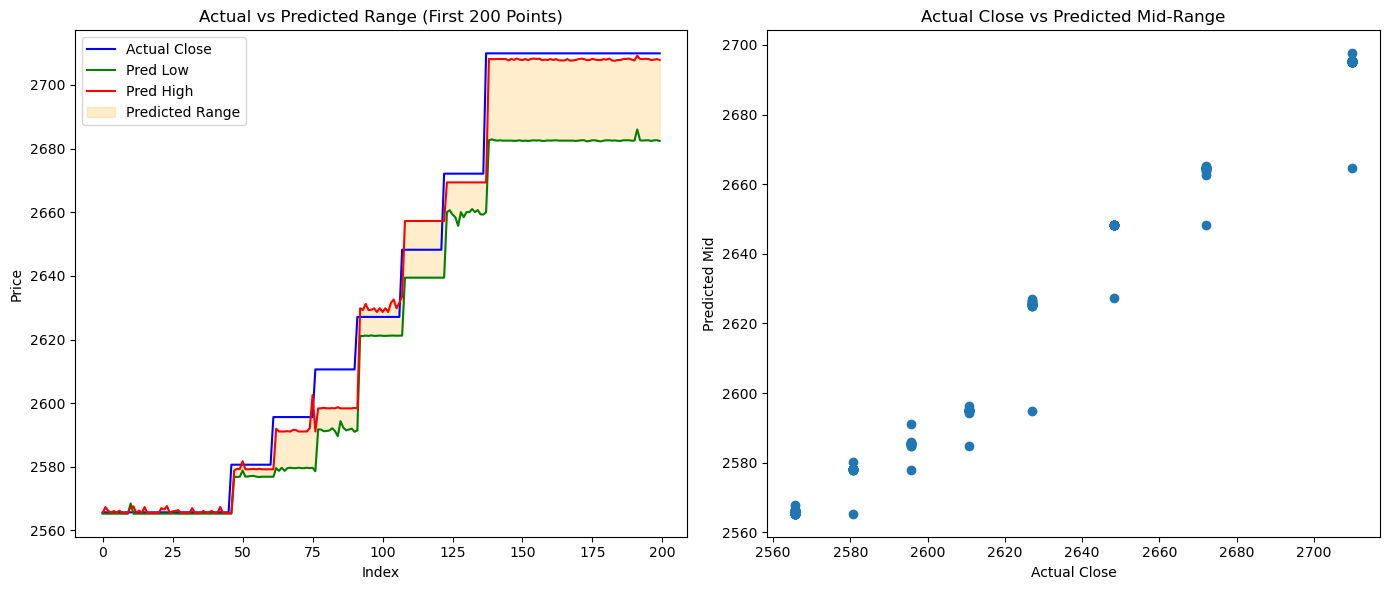

In [5]:
#random forest

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("dataset_unscaled.csv")

# next-day targets
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

# Drop last row (because of shift)
df = df.iloc[:-1]

# Feature selection
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# TRAIN-TEST SPLIT (time series)
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

# Train models
low_model = RandomForestRegressor(n_estimators=300, max_depth=8)
high_model = RandomForestRegressor(n_estimators=300, max_depth=8)

low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)

# Predictions
pred_low = low_model.predict(X_test)
pred_high = high_model.predict(X_test)

# Range accuracy
correct = ((y_close_test >= pred_low) & (y_close_test <= pred_high)).sum()
total = len(y_close_test)
range_accuracy = correct / total

print("\n===== RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high):.4f}")
print(f"Range Accuracy: {range_accuracy * 100:.2f}%")

# 10 sample predictions
sample = pd.DataFrame({
    "Pred Low": pred_low[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high[:10]
})

print("\n===== SAMPLE PREDICTIONS (10 rows) =====")
print(sample)

# =======================================================
# ===================== VISUALIZATION ===================
# =======================================================

# midpoint of predicted range
pred_mid = (pred_low + pred_high) / 2

N = 200  # first 200 points

y_close_200 = y_close_test[:N]
pred_low_200 = pred_low[:N]
pred_high_200 = pred_high[:N]
pred_mid_200 = pred_mid[:N]

plt.figure(figsize=(14,6))

# --- Plot 1: actual vs predicted range
plt.subplot(1,2,1)
plt.plot(y_close_200.values, label="Actual Close", color="blue")
plt.plot(pred_low_200, label="Pred Low", color="green")
plt.plot(pred_high_200, label="Pred High", color="red")
plt.fill_between(range(N), pred_low_200, pred_high_200, alpha=0.2, color="orange", label="Predicted Range")

plt.title("Actual vs Predicted Range (First 200 Points)")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()

# --- Plot 2: scatter actual vs predicted mid-range
plt.subplot(1,2,2)
plt.scatter(y_close_200, pred_mid_200)
plt.title("Actual Close vs Predicted Mid-Range")
plt.xlabel("Actual Close")
plt.ylabel("Predicted Mid")

plt.tight_layout()
plt.show()


In [4]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



===== XGBOOST RANGE MODEL METRICS =====
Low R2:  -0.7002
High R2: -0.7421
Range Accuracy: 14.58%

===== SAMPLE PREDICTIONS (10 rows) =====
      Pred Low  Actual Close    Pred High
0  2564.868164   2565.699951  2566.830566
1  2553.528809   2565.699951  2546.048584
2  2564.989502   2565.699951  2566.296875
3  2565.122559   2565.699951  2566.722656
4  2564.971924   2565.699951  2566.541260
5  2564.896729   2565.699951  2566.674561
6  2565.056396   2565.699951  2566.516602
7  2565.314697   2565.699951  2566.336426
8  2564.449951   2565.699951  2564.753906
9  2565.054688   2565.699951  2566.266113


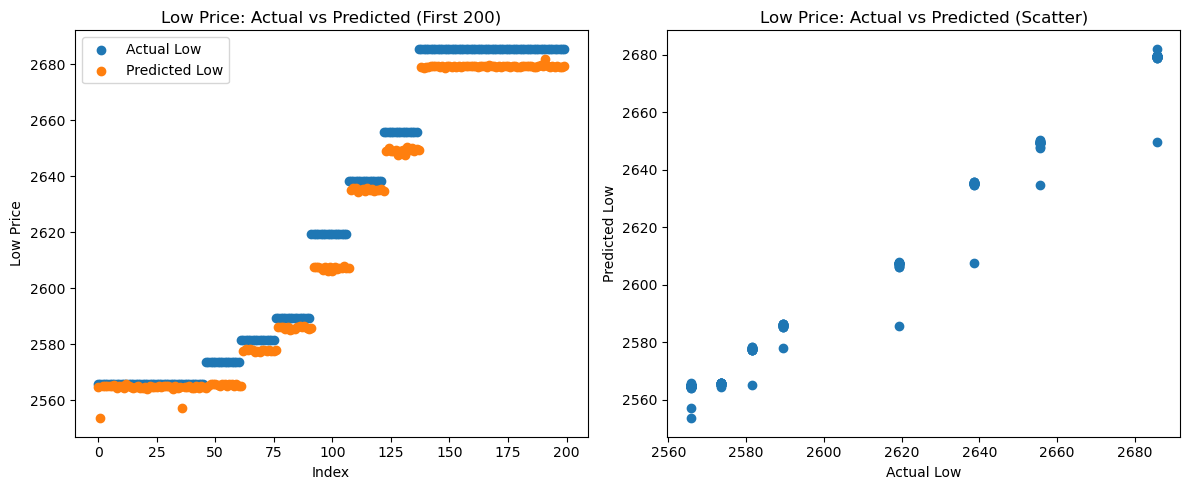

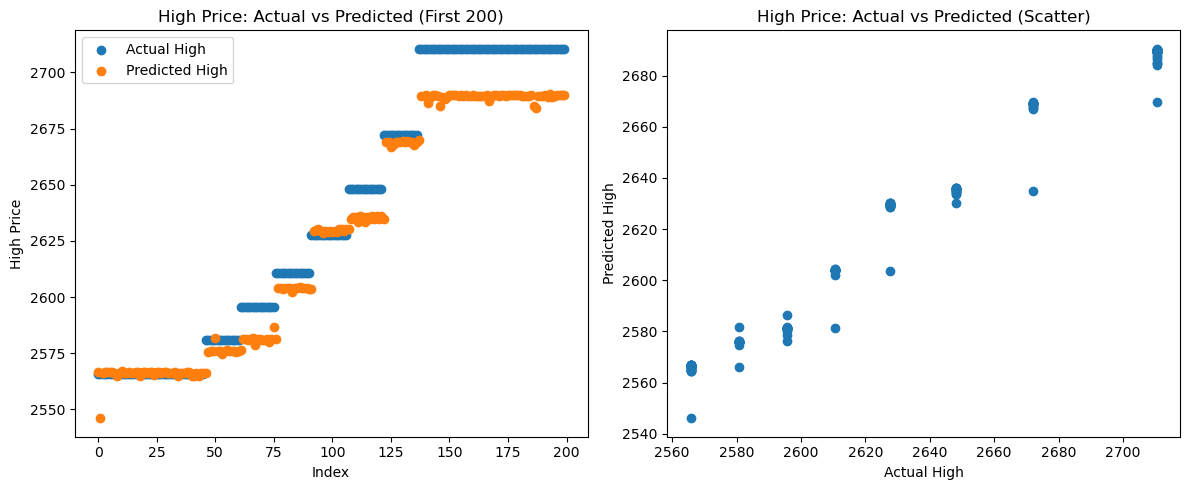

In [6]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# ---------------------------
# LOAD DATA
# ---------------------------
df = pd.read_csv("dataset_unscaled.csv")

df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

df = df.iloc[:-1]

# FEATURES
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# TIME SPLIT
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

# ---------------------------
# TRAIN XGBOOST MODELS
# ---------------------------
low_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

high_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)

# ---------------------------
# PREDICTIONS
# ---------------------------
pred_low = low_model.predict(X_test)
pred_high = high_model.predict(X_test)

# RANGE ACCURACY
correct = ((y_close_test >= pred_low) & (y_close_test <= pred_high)).sum()
total = len(y_close_test)
range_accuracy = correct / total

# ---------------------------
# METRICS
# ---------------------------
print("\n===== XGBOOST RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high):.4f}")
print(f"Range Accuracy: {range_accuracy * 100:.2f}%")

# SAMPLE
sample = pd.DataFrame({
    "Pred Low": pred_low[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high[:10]
})
print("\n===== SAMPLE PREDICTIONS (10 rows) =====")
print(sample)

# ---------------------------
# VISUALIZATIONS
# ---------------------------

# Plot: Actual vs Predicted LOW
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(range(len(y_low_test[:200])), y_low_test[:200], label="Actual Low")
plt.scatter(range(len(pred_low[:200])), pred_low[:200], label="Predicted Low")
plt.title("Low Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("Low Price")
plt.legend()

# Scatter plot actual vs predicted low
plt.subplot(1,2,2)
plt.scatter(y_low_test[:200], pred_low[:200])
plt.title("Low Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual Low")
plt.ylabel("Predicted Low")

plt.tight_layout()
plt.show()


# Plot: Actual vs Predicted HIGH
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(range(len(y_high_test[:200])), y_high_test[:200], label="Actual High")
plt.scatter(range(len(pred_high[:200])), pred_high[:200], label="Predicted High")
plt.title("High Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("High Price")
plt.legend()

# Scatter plot actual vs predicted high
plt.subplot(1,2,2)
plt.scatter(y_high_test[:200], pred_high[:200])
plt.title("High Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual High")
plt.ylabel("Predicted High")

plt.tight_layout()
plt.show()



===== ADA BOOST RANGE MODEL METRICS =====
Low R2:  -0.7290
High R2: -0.7349
Range Accuracy: 20.50%

===== SAMPLE PREDICTIONS (10 rows) =====
      Pred Low  Actual Close    Pred High
0  2565.576904   2565.699951  2574.939913
1  2565.576904   2565.699951  2574.939913
2  2565.576904   2565.699951  2574.939913
3  2565.576904   2565.699951  2574.939913
4  2565.576904   2565.699951  2574.939913
5  2565.576904   2565.699951  2574.939913
6  2565.576904   2565.699951  2574.939913
7  2565.576904   2565.699951  2574.939913
8  2565.576904   2565.699951  2574.939913
9  2565.576904   2565.699951  2574.939913


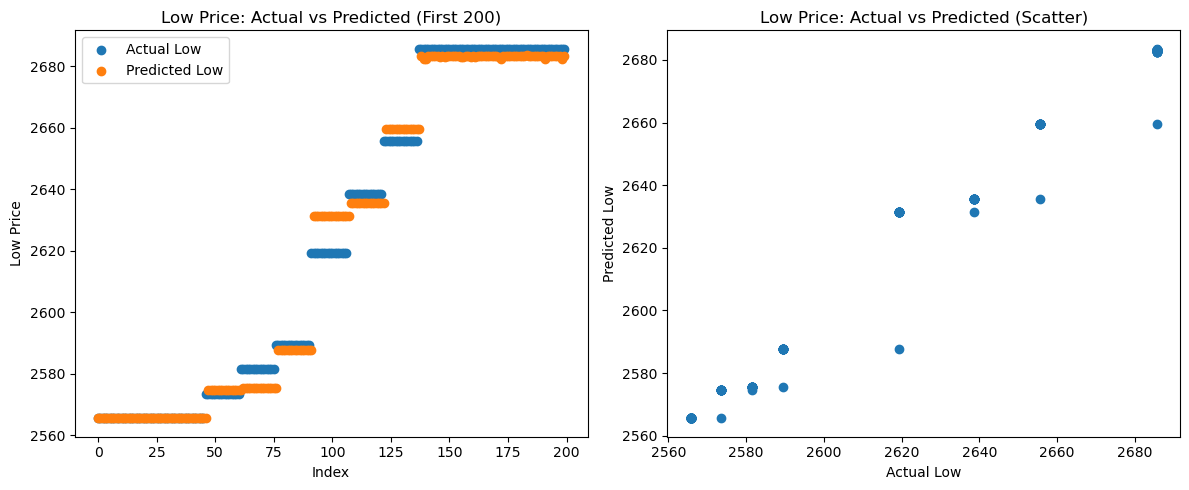

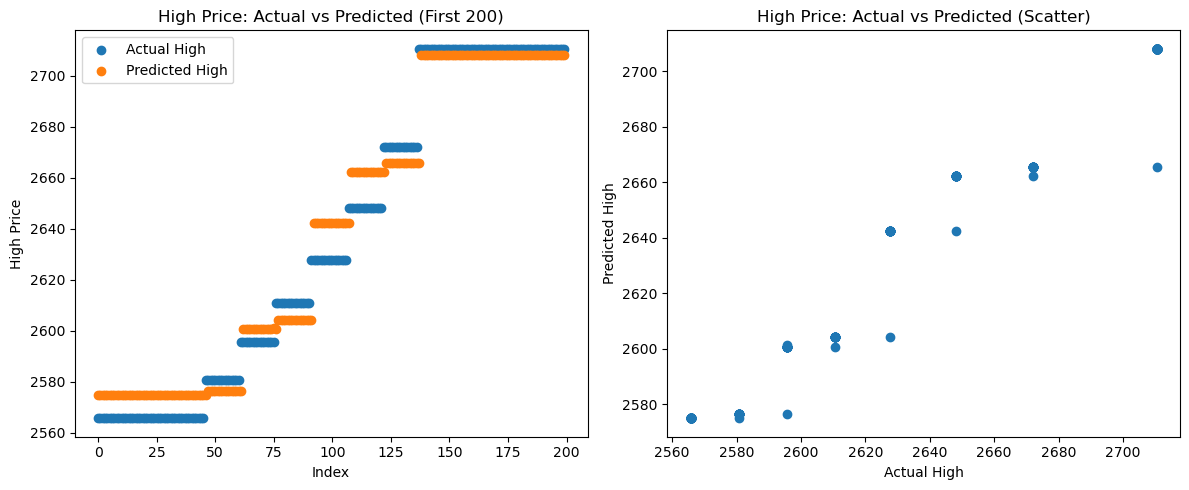

In [7]:
#Adaboost

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# ---------------------------
# LOAD DATA
# ---------------------------
df = pd.read_csv("dataset_unscaled.csv")

# next-day targets
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

df = df.iloc[:-1]

# FEATURES
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# TIME SPLIT
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]


# ---------------------------
# ADA BOOST MODELS
# ---------------------------

# Weak learner (base estimator)
base = DecisionTreeRegressor(max_depth=5)

low_model = AdaBoostRegressor(
    estimator=base,
    n_estimators=300,
    learning_rate=0.05,
    loss='linear'
)

high_model = AdaBoostRegressor(
    estimator=base,
    n_estimators=300,
    learning_rate=0.05,
    loss='linear'
)

# Train
low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)


# ---------------------------
# PREDICTIONS
# ---------------------------
pred_low = low_model.predict(X_test)
pred_high = high_model.predict(X_test)

# RANGE ACCURACY
correct = ((y_close_test >= pred_low) & (y_close_test <= pred_high)).sum()
range_accuracy = correct / len(y_close_test)


# ---------------------------
# METRICS
# ---------------------------
print("\n===== ADA BOOST RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high):.4f}")
print(f"Range Accuracy: {range_accuracy * 100:.2f}%")

# SAMPLE OUTPUT
sample = pd.DataFrame({
    "Pred Low": pred_low[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high[:10]
})
print("\n===== SAMPLE PREDICTIONS (10 rows) =====")
print(sample)


# ---------------------------
# VISUALIZATION — LOW
# ---------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(range(len(y_low_test[:200])), y_low_test[:200], label="Actual Low")
plt.scatter(range(len(pred_low[:200])), pred_low[:200], label="Predicted Low")
plt.title("Low Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("Low Price")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_low_test[:200], pred_low[:200])
plt.title("Low Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual Low")
plt.ylabel("Predicted Low")

plt.tight_layout()
plt.show()


# ---------------------------
# VISUALIZATION — HIGH
# ---------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(range(len(y_high_test[:200])), y_high_test[:200], label="Actual High")
plt.scatter(range(len(pred_high[:200])), pred_high[:200], label="Predicted High")
plt.title("High Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("High Price")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_high_test[:200], pred_high[:200])
plt.title("High Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual High")
plt.ylabel("Predicted High")

plt.tight_layout()
plt.show()


## Linear Regression


===== LINEAR REGRESSION RANGE MODEL METRICS =====
Low R2:  0.9998
High R2: 0.9999
Range Accuracy: 0.00%

===== SAMPLE PREDICTIONS (10 rows) =====
   Pred Low  Actual Close  Pred High
0  0.566252   2565.699951   0.521304
1  0.566005   2565.699951   0.521020
2  0.565975   2565.699951   0.521004
3  0.566141   2565.699951   0.521213
4  0.566015   2565.699951   0.521091
5  0.566150   2565.699951   0.521204
6  0.565968   2565.699951   0.520999
7  0.566045   2565.699951   0.521068
8  0.566062   2565.699951   0.521080
9  0.566064   2565.699951   0.521073


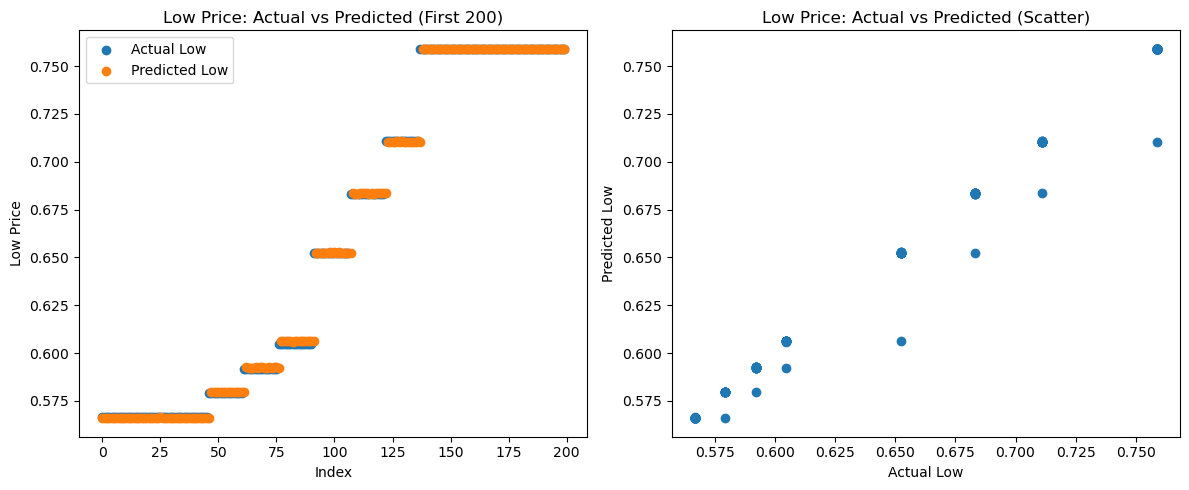

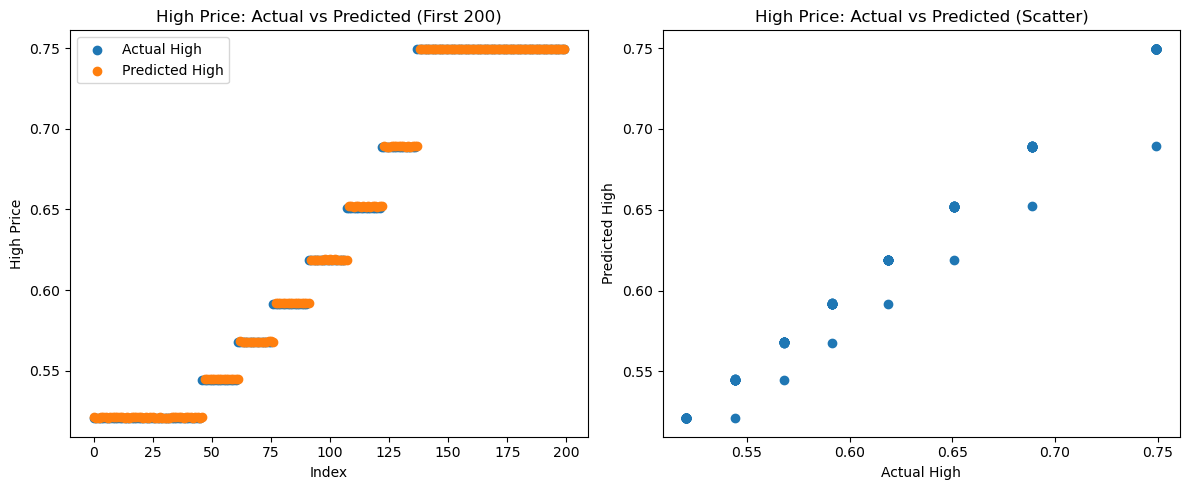

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ---------------------------
# LOAD DATA
# ---------------------------
df = pd.read_csv("dataset_scaled.csv")

# next-day targets
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

# drop last row because of shift
df = df.iloc[:-1]

# FEATURES: all numeric except targets
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# ---------------------------
# TIME-SERIES TRAIN-TEST SPLIT
# ---------------------------
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

# ---------------------------
# LINEAR REGRESSION MODELS
# ---------------------------
low_model = LinearRegression()
high_model = LinearRegression()

# TRAIN
low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)

# PREDICTIONS
pred_low = low_model.predict(X_test)
pred_high = high_model.predict(X_test)

# ---------------------------
# RANGE ACCURACY
# ---------------------------
correct = ((y_close_test >= pred_low) & (y_close_test <= pred_high)).sum()
range_accuracy = correct / len(y_close_test)

# ---------------------------
# METRICS
# ---------------------------
print("\n===== LINEAR REGRESSION RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high):.4f}")
print(f"Range Accuracy: {range_accuracy * 100:.2f}%")

# ---------------------------
# SAMPLE PREDICTIONS (10 rows)
# ---------------------------
sample = pd.DataFrame({
    "Pred Low": pred_low[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high[:10]
})
print("\n===== SAMPLE PREDICTIONS (10 rows) =====")
print(sample)

# ---------------------------
# VISUALIZATION — LOW
# ---------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(range(len(y_low_test[:200])), y_low_test[:200], label="Actual Low")
plt.scatter(range(len(pred_low[:200])), pred_low[:200], label="Predicted Low")
plt.title("Low Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("Low Price")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_low_test[:200], pred_low[:200])
plt.title("Low Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual Low")
plt.ylabel("Predicted Low")

plt.tight_layout()
plt.show()

# ---------------------------
# VISUALIZATION — HIGH
# ---------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(range(len(y_high_test[:200])), y_high_test[:200], label="Actual High")
plt.scatter(range(len(pred_high[:200])), pred_high[:200], label="Predicted High")
plt.title("High Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("High Price")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_high_test[:200], pred_high[:200])
plt.title("High Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual High")
plt.ylabel("Predicted High")

plt.tight_layout()
plt.show()


## K Means Clustering

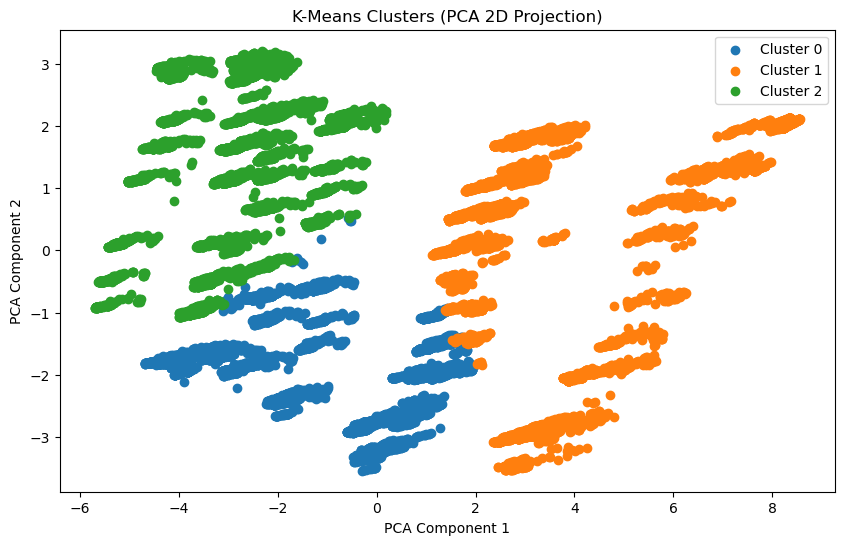


===== CLUSTER SUMMARY =====
              low                                    high                      \
             mean       std       min       max      mean       std       min   
cluster                                                                         
0       -0.347242  0.371082 -1.218725  0.300981 -0.343748  0.370497 -1.188418   
1        1.124940  0.857961  0.114639  2.845493  1.122906  0.861643  0.115495   
2       -0.770350  0.305947 -1.517077 -0.233732 -0.771427  0.304506 -1.526838   

                         close                                        
              max         mean         std          min          max  
cluster                                                               
0        0.304822  2006.315069  233.562799  1477.300049  2426.666585  
1        2.864407  2933.387400  545.514984  2291.399902  4043.300049  
2       -0.167470  1739.923065  191.899876  1269.300049  2081.899902  

Sample days in Cluster 0:
            close       low    

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# -----------------------------
# 1. Load scaled dataset
# -----------------------------
df = pd.read_csv("dataset_scaled.csv")  # already scaled
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# optionally drop target/price if you don't want it to influence clusters
features_to_use = [f for f in numeric_features if f not in ['close', 'low', 'high']]

X = df[features_to_use].values

# -----------------------------
# 2. Apply K-Means clustering
# -----------------------------
k = 3  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# -----------------------------
# 3. Apply PCA for 2D visualization
# -----------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10,6))
for cluster in range(k):
    plt.scatter(
        X_pca[df['cluster'] == cluster, 0],
        X_pca[df['cluster'] == cluster, 1],
        label=f"Cluster {cluster}"
    )

plt.title("K-Means Clusters (PCA 2D Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

# -----------------------------
# 4. Analyze clusters
# -----------------------------
cluster_summary = df.groupby('cluster')[['low','high','close']].agg(['mean','std','min','max'])
print("\n===== CLUSTER SUMMARY =====")
print(cluster_summary)

# -----------------------------
# 5. Optional: Sample some cluster members
# -----------------------------
for cluster in range(k):
    print(f"\nSample days in Cluster {cluster}:")
    print(df[df['cluster']==cluster][['close','low','high']].head(5))


## Neural Network Perceptron

In [14]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/331.9 MB 2.1 MB/s eta 0:02:39
   ---------------------------------------- 1.6/331.9 MB 3.5 MB/s eta 0:01:35
   ---------------------------------------- 2.1/331.9 MB 3.2 MB/s eta 0:01:44
   ---------------------------------------- 2.4/331.9 MB 3.1 MB/s eta 0:01:46
   ---------------------------------------- 2.4/331.9 MB 3.1 MB/s eta 0:01:46
   ---------------------------------------- 2.4/331.9 MB 3.1 MB/s eta 0:01:46
   ---------------------------------------- 2.4/331.9 MB 3.1 MB/s eta 0:01:46
   ---------------------------------------- 2.6/331.9 MB 1.5 MB/s eta 0:03:39
   ---------------------------------------- 2.6/331.9 MB 1.5 MB/s eta 0:03:39
   ---------------------------------------- 3.1/331.9 MB 1.4 MB/s eta 0:03:50


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.1 which is incompatible.


C:\Users\Dell\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Low R2:  0.8277
High R2: 0.7034
Range Accuracy: 0.00%


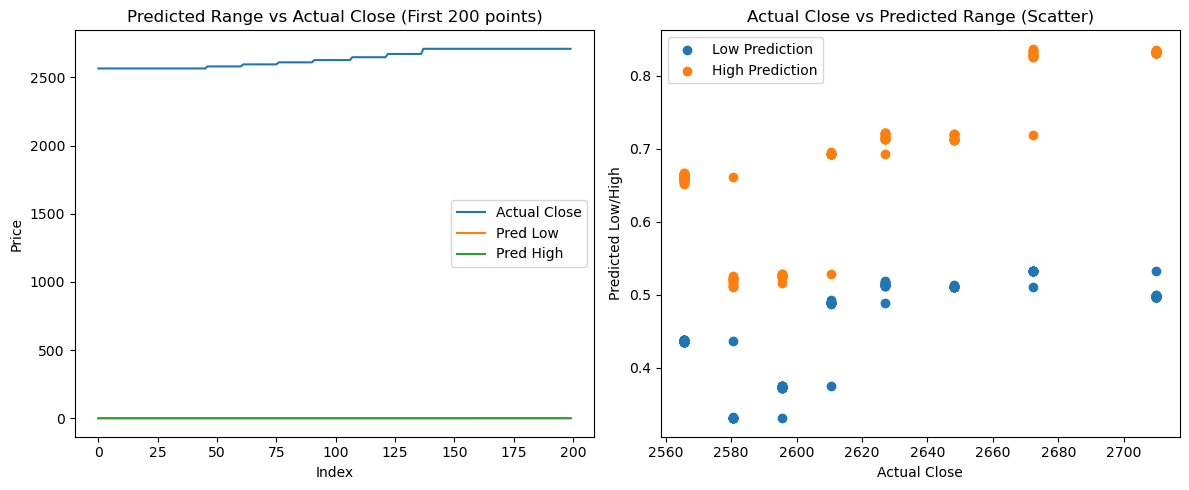

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

df = pd.read_csv("dataset_scaled.csv")

# --- Create next-day targets ---
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

# Drop last row (because of shift)
df = df.iloc[:-1]

features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features].values
y_low = df["low_next"].values
y_high = df["high_next"].values
y_close = df["close_next"].values


# Reduce to top N components 
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X)

train_size = int(len(X_pca) * 0.8)
X_train, X_test = X_pca[:train_size], X_pca[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]


# Build MLP model
def build_mlp(input_dim):
    model = Sequential([
        Dense(64, input_dim=input_dim, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

low_model = build_mlp(X_train.shape[1])
high_model = build_mlp(X_train.shape[1])

# Train models
low_model.fit(X_train, y_low_train, validation_split=0.1, epochs=50, batch_size=32, verbose=0)
high_model.fit(X_train, y_high_train, validation_split=0.1, epochs=50, batch_size=32, verbose=0)

pred_low = low_model.predict(X_test).flatten()
pred_high = high_model.predict(X_test).flatten()

correct = ((y_close_test >= pred_low) & (y_close_test <= pred_high)).sum()
range_accuracy = correct / len(y_close_test)

print(f"Low R2:  {r2_score(y_low_test, pred_low):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high):.4f}")
print(f"Range Accuracy: {range_accuracy * 100:.2f}%")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(len(y_close_test[:200])), y_close_test[:200], label="Actual Close")
plt.plot(range(len(pred_low[:200])), pred_low[:200], label="Pred Low")
plt.plot(range(len(pred_high[:200])), pred_high[:200], label="Pred High")
plt.title("Predicted Range vs Actual Close (First 200 points)")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_close_test[:200], pred_low[:200], label="Low Prediction")
plt.scatter(y_close_test[:200], pred_high[:200], label="High Prediction")
plt.title("Actual Close vs Predicted Range (Scatter)")
plt.xlabel("Actual Close")
plt.ylabel("Predicted Low/High")
plt.legend()

plt.tight_layout()
plt.show()


## Gradient Descent


===== GRADIENT DESCENT RANGE MODEL =====
Low R2:  0.9548
High R2: 0.9491
Range Accuracy: 0.00%


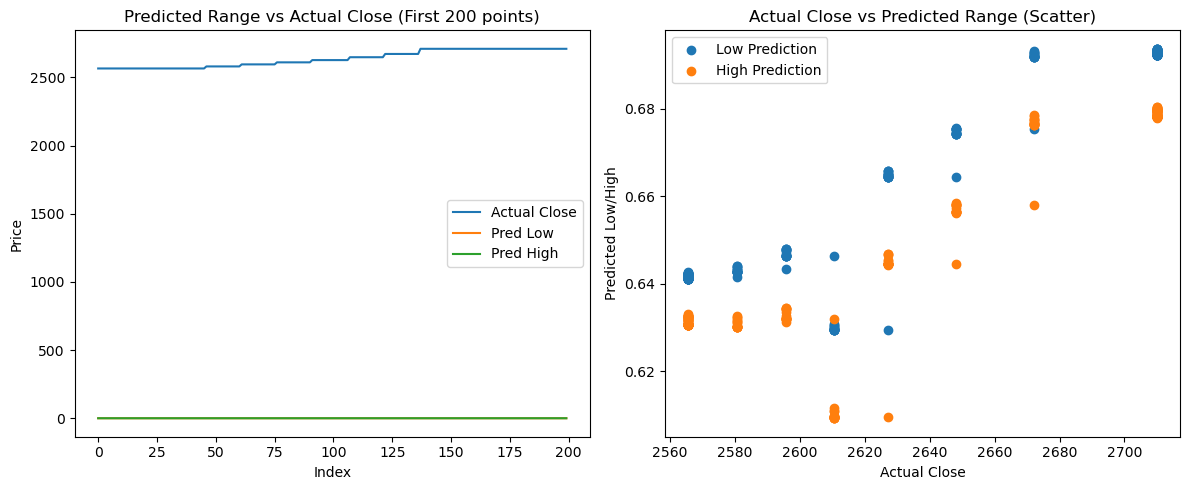

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score

df = pd.read_csv("dataset_scaled.csv")

# Create next-day targets
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

# Drop last row (because of shift)
df = df.iloc[:-1]

features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features].values
y_low = df["low_next"].values
y_high = df["high_next"].values
y_close = df["close_next"].values

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X)

# Train-test split (time series)

train_size = int(len(X_pca) * 0.8)
X_train, X_test = X_pca[:train_size], X_pca[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

class LinearRegressorGD:
    def __init__(self, lr=0.001, epochs=5000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.X = np.c_[np.ones(X.shape[0]), X]  # add bias term
        self.y = y.reshape(-1,1)
        self.theta = np.zeros((self.X.shape[1], 1))
        
        for _ in range(self.epochs):
            predictions = self.X @ self.theta
            error = predictions - self.y
            gradient = (self.X.T @ error) / len(self.y)
            self.theta -= self.lr * gradient

    def predict(self, X):
        X_ = np.c_[np.ones(X.shape[0]), X]
        return (X_ @ self.theta).flatten()

#Train separate GD models
low_model = LinearRegressorGD(lr=0.01, epochs=5000)
high_model = LinearRegressorGD(lr=0.01, epochs=5000)

low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)

pred_low = low_model.predict(X_test)
pred_high = high_model.predict(X_test)

correct = ((y_close_test >= pred_low) & (y_close_test <= pred_high)).sum()
range_accuracy = correct / len(y_close_test)

#Evaluation metrics
print("\n===== GRADIENT DESCENT RANGE MODEL =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high):.4f}")
print(f"Range Accuracy: {range_accuracy * 100:.2f}%")

# Visualization
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(len(y_close_test[:200])), y_close_test[:200], label="Actual Close")
plt.plot(range(len(pred_low[:200])), pred_low[:200], label="Pred Low")
plt.plot(range(len(pred_high[:200])), pred_high[:200], label="Pred High")
plt.title("Predicted Range vs Actual Close (First 200 points)")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_close_test[:200], pred_low[:200], label="Low Prediction")
plt.scatter(y_close_test[:200], pred_high[:200], label="High Prediction")
plt.title("Actual Close vs Predicted Range (Scatter)")
plt.xlabel("Actual Close")
plt.ylabel("Predicted Low/High")
plt.legend()

plt.tight_layout()
plt.show()


### Comparisons

In [ ]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

models = {
    "Random Forest": (pred_low_rf, pred_high_rf),
    "KNN": (pred_low_knn, pred_high_knn),
    "Decision Tree": (pred_low_dt, pred_high_dt),
    "SVM": (pred_low_svm, pred_high_svm),
    "XGBoost": (pred_low_xgb, pred_high_xgb),
    "AdaBoost": (pred_low_ada, pred_high_ada),
    "Linear Regression": (pred_low_lr, pred_high_lr),
    "Neural Net": (pred_low_nn, pred_high_nn),
    "Gradient Descent": (pred_low_gd, pred_high_gd)
}

# Metrics calculation
results = []

for name, (pred_low, pred_high) in models.items():
    low_r2 = r2_score(y_low_test, pred_low)
    high_r2 = r2_score(y_high_test, pred_high)
    mse_low = mean_squared_error(y_low_test, pred_low)
    mse_high = mean_squared_error(y_high_test, pred_high)
    
    # Range accuracy
    correct = ((y_close_test >= pred_low) & (y_close_test <= pred_high)).sum()
    range_acc = correct / len(y_close_test)
    
    results.append({
        "Model": name,
        "Low R2": low_r2,
        "High R2": high_r2,
        "MSE Low": mse_low,
        "MSE High": mse_high,
        "Range Accuracy": range_acc
    })

df_results = pd.DataFrame(results)
print("\n===== MODEL COMPARISON =====")
print(df_results)

# visualization
plt.figure(figsize=(15,10))

for i, (name, (pred_low, pred_high)) in enumerate(models.items(), 1):
    plt.subplot(3,3,i)
    plt.plot(range(200), y_close_test[:200], label="Actual Close")
    plt.plot(range(200), pred_low[:200], label="Pred Low")
    plt.plot(range(200), pred_high[:200], label="Pred High")
    plt.title(name)
    plt.xlabel("Index")
    plt.ylabel("Price")
    plt.legend()

plt.tight_layout()
plt.show()
